# Эксперимент 16: Бенчмарк row-моделей (MRL + NT-Xent)

Сравнение 7 токен-моделей, успешно прошедших пайплайн `embeddings → build → train` из `16_benchmark_row_models.py`:

| tag | hidden_dim | pooling | prefix |
|---|---|---|---|
| `rubert-tiny2` (baseline) | 312 | cls | — |
| `minilm-l12` | 384 | mean | — |
| `e5-base` | 768 | mean | `query: ` |
| `labse-en-ru` | 768 | cls | — |
| `sbert-ru-large` | 1024 | mean | — |
| `e5-large` | 1024 | mean | `query: ` |
| `bge-m3` | 1024 | cls | — |

`gte-multilingual` упала на шаге `embeddings` (trust_remote_code) — исключена.

Разделы:
1. Сводка по стоимости (время каждого шага, из `benchmark_row_models.json`)
2. Кривые обучения — все модели на одном графике
3. Оценка: val → θ → in-domain test + cross-domain (F1 / P / R / ROC-AUC / AP)
4. Сводная таблица и рейтинг моделей
5. Cross-domain по датасетам

Все оценки кешируются в `output/<tag>/v14_benchmark_evaluation.json`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output")
BENCH_SUMMARY = OUTPUT_DIR / "benchmark_row_models.json"

# Порядок = ось hidden_dim (по возрастанию), baseline первый
MODEL_TAGS = [
    "rubert-tiny2", "minilm-l12", "e5-base", "labse-en-ru",
    "sbert-ru-large", "e5-large", "bge-m3",
]
MODEL_COLORS = {
    "rubert-tiny2":   "#9E9E9E",
    "minilm-l12":     "#2196F3",
    "e5-base":        "#4CAF50",
    "labse-en-ru":    "#FF9800",
    "sbert-ru-large": "#9C27B0",
    "e5-large":       "#E91E63",
    "bge-m3":         "#00BCD4",
}
MODEL_HIDDEN = {
    "rubert-tiny2":   312,
    "minilm-l12":     384,
    "e5-base":        768,
    "labse-en-ru":    768,
    "sbert-ru-large": 1024,
    "e5-large":       1024,
    "bge-m3":         1024,
}


def model_paths(tag: str) -> tuple[Path, Path, Path, Path]:
    """state_dict, config, history, MRL-граф для данного model_tag."""
    base = OUTPUT_DIR / tag / "v14_mrl_gat_model"
    graph_dir = DATA_DIR / "graphs" / tag / "v14_mrl"
    return base.with_suffix(".pt"), base.with_suffix(".config.json"), base.with_suffix(".history.json"), graph_dir


def cross_dir(tag: str) -> Path:
    return DATA_DIR / "graphs" / tag / "v14_mrl_cross"


print("Доступность артефактов:")
for tag in MODEL_TAGS:
    mp, cp, hp, gd = model_paths(tag)
    print(f"  [{tag:16s}] model={'✓' if mp.exists() else '✗'}  "
          f"cfg={'✓' if cp.exists() else '✗'}  "
          f"hist={'✓' if hp.exists() else '✗'}  "
          f"graph={'✓' if (gd / 'graph.pt').exists() else '✗'}  "
          f"cross={'✓' if cross_dir(tag).exists() else '✗'}")

Доступность артефактов:
  [rubert-tiny2    ] model=✓  cfg=✓  hist=✗  graph=✓  cross=✓
  [minilm-l12      ] model=✓  cfg=✓  hist=✓  graph=✓  cross=✓
  [e5-base         ] model=✓  cfg=✓  hist=✓  graph=✓  cross=✓
  [labse-en-ru     ] model=✓  cfg=✓  hist=✓  graph=✓  cross=✓
  [sbert-ru-large  ] model=✓  cfg=✓  hist=✓  graph=✓  cross=✓
  [e5-large        ] model=✓  cfg=✓  hist=✓  graph=✓  cross=✓
  [bge-m3          ] model=✓  cfg=✓  hist=✓  graph=✓  cross=✓


---
## 1. Стоимость бенчмарка (wall-clock time)

                hidden_dim  embeddings_min  build_min  train_min  total_min
tag                                                                        
rubert-tiny2           312             NaN        NaN        NaN        0.0
minilm-l12             384            13.3        7.2       13.6       34.1
e5-base                768            31.2        7.3       11.5       50.0
labse-en-ru            768            27.9        7.7        8.9       44.5
sbert-ru-large        1024           110.3        7.1       13.0      130.4
e5-large              1024            58.1        6.6       20.6       85.3
bge-m3                1024           126.9        6.8        8.5      142.1


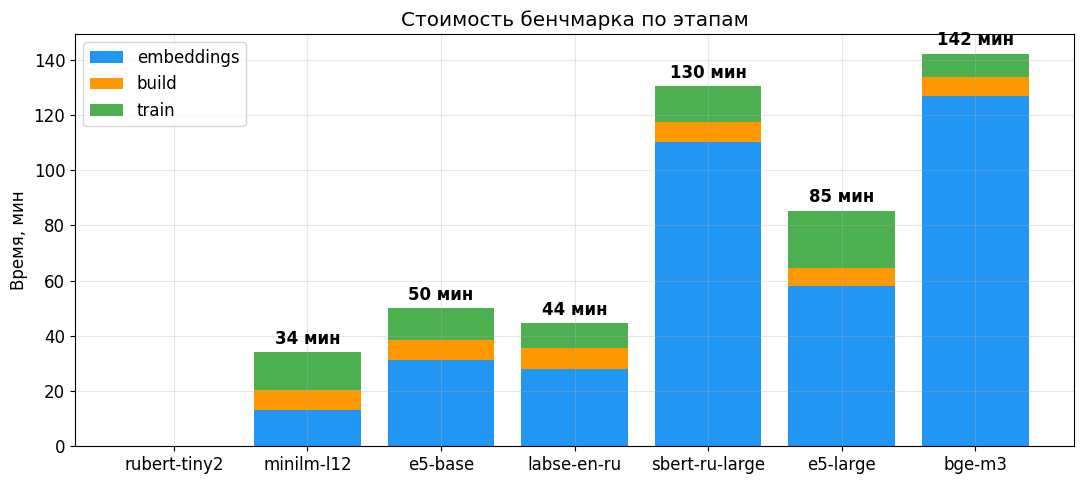

In [2]:
if BENCH_SUMMARY.exists():
    with open(BENCH_SUMMARY) as f:
        bench = json.load(f)

    rows = []
    for rec in bench["models"]:
        if rec["tag"] not in MODEL_TAGS:
            continue
        steps = rec.get("steps", {})
        emb = steps.get("embeddings", {}).get("duration_sec")
        build = steps.get("build", {}).get("duration_sec")
        train = steps.get("train", {}).get("duration_sec")
        rows.append({
            "tag": rec["tag"],
            "hidden_dim": rec["hidden_dim"],
            "embeddings_min": round(emb / 60, 1) if emb else None,
            "build_min":      round(build / 60, 1) if build else None,
            "train_min":      round(train / 60, 1) if train else None,
            "total_min":      round(sum(v for v in [emb, build, train] if v) / 60, 1),
        })
    # rubert-tiny2 был skipped (артефакты уже были) — отдельно помечаем
    bench_df = pd.DataFrame(rows).set_index("tag").reindex(MODEL_TAGS)
    print(bench_df.to_string())

    durations = bench_df[["embeddings_min", "build_min", "train_min"]].fillna(0)
    fig, ax = plt.subplots(figsize=(11, 5))
    bottom = np.zeros(len(durations))
    for step, color in [("embeddings_min", "#2196F3"), ("build_min", "#FF9800"), ("train_min", "#4CAF50")]:
        vals = durations[step].values
        ax.bar(durations.index, vals, bottom=bottom, color=color, label=step.replace("_min", ""))
        bottom += vals
    for i, total in enumerate(bottom):
        if total > 0:
            ax.text(i, total + 3, f"{total:.0f} мин", ha="center", fontweight="bold")
    ax.set_ylabel("Время, мин")
    ax.set_title("Стоимость бенчмарка по этапам")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Сводка не найдена: {BENCH_SUMMARY}")

---
## 2. Кривые обучения — все модели на одной оси

In [3]:
histories: dict[str, dict] = {}
for tag in MODEL_TAGS:
    _, _, hp, _ = model_paths(tag)
    if hp.exists():
        with open(hp) as f:
            histories[tag] = json.load(f)

for tag, h in histories.items():
    n = len(h["train_loss"])
    line = f"[{tag:16s}] эпох={n:4d}  final_train={h['train_loss'][-1]:.4f}"
    if h.get("val_loss"):
        best = int(np.argmin(h["val_loss"]))
        line += f"  best_val={h['val_loss'][best]:.4f} (ep {best + 1})"
    print(line)

[minilm-l12      ] эпох= 373  final_train=0.1367  best_val=1.1354 (ep 343)
[e5-base         ] эпох= 228  final_train=0.0929  best_val=0.5192 (ep 198)
[labse-en-ru     ] эпох= 215  final_train=0.1014  best_val=0.7852 (ep 185)
[sbert-ru-large  ] эпох= 275  final_train=0.2706  best_val=1.4753 (ep 245)
[e5-large        ] эпох= 385  final_train=0.0407  best_val=0.3517 (ep 355)
[bge-m3          ] эпох= 163  final_train=0.1039  best_val=0.3256 (ep 133)


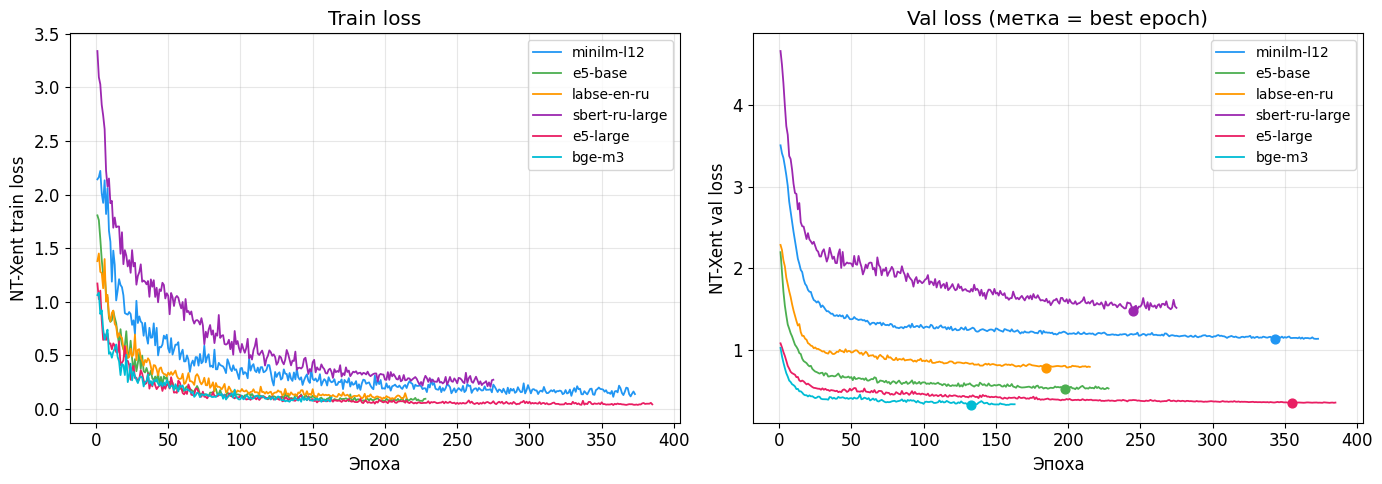

In [4]:
if histories:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for tag, h in histories.items():
        color = MODEL_COLORS[tag]
        epochs = list(range(1, len(h["train_loss"]) + 1))
        axes[0].plot(epochs, h["train_loss"], color=color, linewidth=1.3, label=tag)
        if h.get("val_loss"):
            v_ep = list(range(1, len(h["val_loss"]) + 1))
            axes[1].plot(v_ep, h["val_loss"], color=color, linewidth=1.3, label=tag)
            best = int(np.argmin(h["val_loss"]))
            axes[1].scatter([best + 1], [h["val_loss"][best]], color=color, s=40, zorder=5)

    axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("NT-Xent train loss")
    axes[0].set_title("Train loss"); axes[0].legend(fontsize=10)
    axes[1].set_xlabel("Эпоха"); axes[1].set_ylabel("NT-Xent val loss")
    axes[1].set_title("Val loss (метка = best epoch)"); axes[1].legend(fontsize=10)
    plt.tight_layout()
    plt.show()

---
## 3. Оценка: val → θ → in-domain test + cross-domain

Процедура повторяет exp 10 / exp 14 analysis: ищем оптимальный θ на val, применяем его к test и к 3 cross-domain датасетам (anime / citations / electronics).

Результаты кешируются в `output/<tag>/v14_benchmark_evaluation.json`.

In [5]:
from table_unifier.evaluation.clustering import (
    evaluate_pairs_at_threshold,
    evaluate_pairs_auc,
    find_best_threshold,
)
from table_unifier.models.entity_resolution import EntityResolutionGAT
from table_unifier.training.er_trainer import get_row_embeddings

device = "cuda" if torch.cuda.is_available() else "cpu"


def build_backbone(cfg: dict) -> EntityResolutionGAT:
    return EntityResolutionGAT(
        row_dim=cfg["row_dim"], token_dim=cfg["token_dim"], col_dim=cfg["col_dim"],
        hidden_dim=cfg["hidden_dim"], edge_dim=cfg["edge_dim"], output_dim=cfg["output_dim"],
        num_gnn_layers=cfg["num_gnn_layers"], num_heads=cfg["num_heads"],
        dropout=cfg["dropout"], attention_dropout=cfg["attention_dropout"],
        bidirectional=cfg["bidirectional"],
        use_input_projection=cfg["use_input_projection"],
    )


def load_backbone(model_path: Path, cfg: dict) -> EntityResolutionGAT:
    backbone = build_backbone(cfg)
    state = torch.load(model_path, map_location=device, weights_only=True)
    backbone.load_state_dict(state)
    backbone.to(device).eval()
    return backbone


def evaluate_model(tag: str) -> dict:
    mp, cp, _, gd = model_paths(tag)
    if not mp.exists() or not cp.exists() or not (gd / "graph.pt").exists():
        return {}
    with open(cp) as f:
        cfg = json.load(f)

    graph = torch.load(gd / "graph.pt", weights_only=False)
    val_pairs = torch.load(gd / "val_pairs.pt", weights_only=False)
    test_pairs = torch.load(gd / "test_pairs.pt", weights_only=False)

    backbone = load_backbone(mp, cfg)
    emb = get_row_embeddings(backbone, graph, device="cpu")

    threshold, _ = find_best_threshold(emb, val_pairs)
    out = {"tag": tag, "threshold": threshold, "hidden_dim": cfg["hidden_dim"]}
    for split_name, pairs in [("val", val_pairs), ("test", test_pairs)]:
        m = evaluate_pairs_at_threshold(emb, pairs, threshold)
        m.update(evaluate_pairs_auc(emb, pairs))
        out[split_name] = m
    del graph, emb
    torch.cuda.empty_cache()

    cross = []
    cdir = cross_dir(tag)
    if cdir.exists():
        for ds in sorted(cdir.iterdir()):
            if not ds.is_dir() or not (ds / "graph.pt").exists():
                continue
            cg = torch.load(ds / "graph.pt", weights_only=False)
            bb = load_backbone(mp, cfg)
            cd_emb = get_row_embeddings(bb, cg, device="cpu")
            rec = {"name": ds.name}
            lp_path = ds / "labeled_pairs.pt"
            if lp_path.exists():
                lp = torch.load(lp_path, weights_only=False)
                metrics = evaluate_pairs_at_threshold(cd_emb, lp, threshold)
                metrics.update(evaluate_pairs_auc(cd_emb, lp))
                rec.update(metrics)
            cross.append(rec)
            del cg, cd_emb
            torch.cuda.empty_cache()
    out["cross_domain"] = cross
    return out


results: dict[str, dict] = {}
for tag in MODEL_TAGS:
    cached = OUTPUT_DIR / tag / "v14_benchmark_evaluation.json"
    if cached.exists():
        with open(cached) as f:
            results[tag] = json.load(f)
        print(f"  [{tag:16s}] из кэша {cached.relative_to(OUTPUT_DIR.parent)}")
    else:
        print(f"  [{tag:16s}] оцениваю...")
        r = evaluate_model(tag)
        if r:
            results[tag] = r
            cached.parent.mkdir(parents=True, exist_ok=True)
            with open(cached, "w") as f:
                json.dump(r, f, ensure_ascii=False, indent=2)
        else:
            print(f"  [{tag:16s}] артефакты не найдены — пропуск")

  [rubert-tiny2    ] оцениваю...
  [minilm-l12      ] оцениваю...
  [e5-base         ] оцениваю...
  [labse-en-ru     ] оцениваю...
  [sbert-ru-large  ] оцениваю...
  [e5-large        ] оцениваю...
  [bge-m3          ] оцениваю...


In [6]:
for tag, res in results.items():
    print(f"── [{tag:16s}] hidden={res['hidden_dim']:4d}  θ={res['threshold']:.4f} ──")
    for split_name in ("val", "test"):
        m = res[split_name]
        print(f"  {split_name:5s}: F1={m.get('f1', 0):.4f}  "
              f"P={m.get('precision', 0):.4f}  R={m.get('recall', 0):.4f}  "
              f"AUC={m.get('roc_auc', 0):.4f}  AP={m.get('avg_precision', 0):.4f}")
    for cd in res.get("cross_domain", []):
        print(f"  cross/{cd['name']:12s} F1={cd.get('f1', 0):.4f}  "
              f"P={cd.get('precision', 0):.4f}  R={cd.get('recall', 0):.4f}  "
              f"AUC={cd.get('roc_auc', 0):.4f}")
    print()

── [rubert-tiny2    ] hidden= 312  θ=0.6625 ──
  val  : F1=0.8168  P=0.8209  R=0.8127  AUC=0.8873  AP=0.8898
  test : F1=0.8122  P=0.8230  R=0.8016  AUC=0.8963  AP=0.8861
  cross/anime        F1=0.3243  P=0.9677  R=0.1948  AUC=0.9574
  cross/citations    F1=0.0000  P=0.0000  R=0.0000  AUC=0.6097
  cross/electronics  F1=0.1724  P=1.0000  R=0.0943  AUC=0.9055

── [minilm-l12      ] hidden= 384  θ=0.6095 ──
  val  : F1=0.8000  P=0.7664  R=0.8367  AUC=0.8847  AP=0.8968
  test : F1=0.8083  P=0.7643  R=0.8577  AUC=0.8909  AP=0.8819
  cross/anime        F1=0.6283  P=0.9861  R=0.4610  AUC=0.9903
  cross/citations    F1=0.0000  P=0.0000  R=0.0000  AUC=0.5618
  cross/electronics  F1=0.2333  P=1.0000  R=0.1321  AUC=0.9142

── [e5-base         ] hidden= 768  θ=0.6764 ──
  val  : F1=0.9015  P=0.8834  R=0.9203  AUC=0.9576  AP=0.9581
  test : F1=0.8984  P=0.8762  R=0.9218  AUC=0.9580  AP=0.9521
  cross/anime        F1=0.7059  P=1.0000  R=0.5455  AUC=0.9926
  cross/citations    F1=0.0000  P=0.0000  R=

---
## 4. Сводная таблица: in-domain test по всем моделям

Один датафрейм → основа для таблицы в дипломе.

In [7]:
rows = []
for tag in MODEL_TAGS:
    res = results.get(tag)
    if not res:
        continue
    t = res["test"]; v = res["val"]
    rows.append({
        "tag": tag,
        "hidden": res["hidden_dim"],
        "θ":       round(res["threshold"], 4),
        "Val F1":  round(v.get("f1", 0), 4),
        "Test F1": round(t.get("f1", 0), 4),
        "Test P":  round(t.get("precision", 0), 4),
        "Test R":  round(t.get("recall", 0), 4),
        "Test AUC": round(t.get("roc_auc", 0), 4),
        "Test AP": round(t.get("avg_precision", 0), 4),
    })

summary_df = pd.DataFrame(rows).set_index("tag").reindex([t for t in MODEL_TAGS if t in results])
print("In-domain TEST:")
print(summary_df.to_string())

if "Test F1" in summary_df:
    best_tag = summary_df["Test F1"].idxmax()
    best_auc = summary_df["Test AUC"].idxmax()
    print(f"\nЛучший по Test F1:  {best_tag} ({summary_df.loc[best_tag, 'Test F1']:.4f})")
    print(f"Лучший по Test AUC: {best_auc} ({summary_df.loc[best_auc, 'Test AUC']:.4f})")

In-domain TEST:
                hidden       θ  Val F1  Test F1  Test P  Test R  Test AUC  Test AP
tag                                                                               
rubert-tiny2       312  0.6625  0.8168   0.8122  0.8230  0.8016    0.8963   0.8861
minilm-l12         384  0.6095  0.8000   0.8083  0.7643  0.8577    0.8909   0.8819
e5-base            768  0.6764  0.9015   0.8984  0.8762  0.9218    0.9580   0.9521
labse-en-ru        768  0.6612  0.8438   0.8417  0.7986  0.8898    0.9180   0.9110
sbert-ru-large    1024  0.6687  0.8177   0.8218  0.7992  0.8457    0.9021   0.8998
e5-large          1024  0.6945  0.9191   0.9153  0.9107  0.9198    0.9676   0.9599
bge-m3            1024  0.7300  0.9180   0.9020  0.8829  0.9218    0.9669   0.9633

Лучший по Test F1:  e5-large (0.9153)
Лучший по Test AUC: e5-large (0.9676)


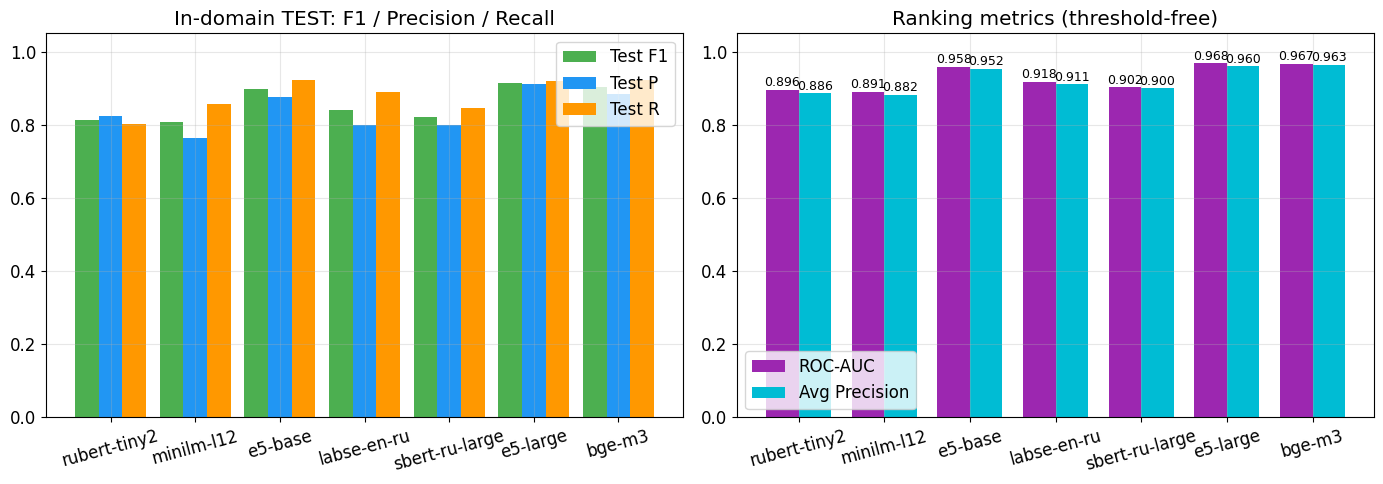

In [8]:
if not summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(summary_df))
    colors = [MODEL_COLORS[t] for t in summary_df.index]

    ax = axes[0]
    w = 0.28
    for i, (col, off) in enumerate([("Test F1", -w), ("Test P", 0), ("Test R", w)]):
        ax.bar(x + off, summary_df[col], w, label=col,
               color={"Test F1": "#4CAF50", "Test P": "#2196F3", "Test R": "#FF9800"}[col])
    ax.set_xticks(x); ax.set_xticklabels(summary_df.index, rotation=15)
    ax.set_ylim(0, 1.05); ax.legend()
    ax.set_title("In-domain TEST: F1 / Precision / Recall")

    ax = axes[1]
    w = 0.38
    ax.bar(x - w/2, summary_df["Test AUC"], w, label="ROC-AUC", color="#9C27B0")
    ax.bar(x + w/2, summary_df["Test AP"], w, label="Avg Precision", color="#00BCD4")
    for i, (auc, ap) in enumerate(zip(summary_df["Test AUC"], summary_df["Test AP"])):
        ax.text(i - w/2, auc + 0.01, f"{auc:.3f}", ha="center", fontsize=9)
        ax.text(i + w/2, ap + 0.01, f"{ap:.3f}", ha="center", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(summary_df.index, rotation=15)
    ax.set_ylim(0, 1.05); ax.legend()
    ax.set_title("Ranking metrics (threshold-free)")
    plt.tight_layout()
    plt.show()

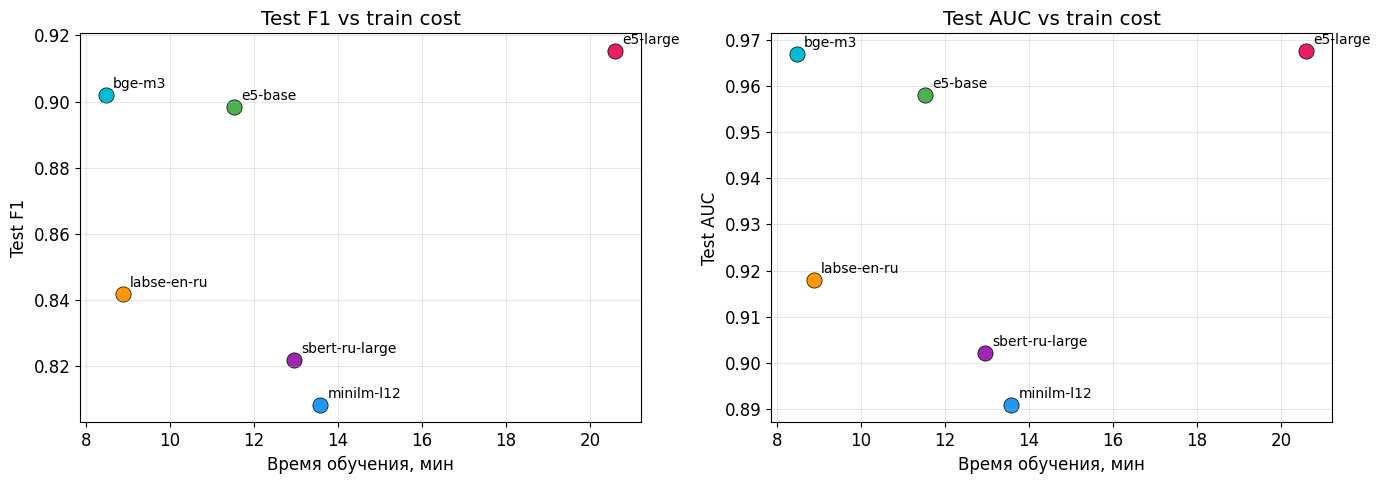

In [9]:
# Качество vs стоимость (train_min) — F1 и AUC как функция времени обучения
if BENCH_SUMMARY.exists() and not summary_df.empty:
    bench_lookup = {rec["tag"]: rec for rec in bench["models"]}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ["Test F1", "Test AUC"]):
        for tag in summary_df.index:
            steps = bench_lookup.get(tag, {}).get("steps", {})
            tr = steps.get("train", {}).get("duration_sec")
            if not tr:
                continue  # rubert-tiny2 skipped в бенчмарке
            ax.scatter(tr / 60, summary_df.loc[tag, metric],
                       s=120, color=MODEL_COLORS[tag], edgecolor="black", linewidth=0.5)
            ax.annotate(tag, (tr / 60, summary_df.loc[tag, metric]),
                        xytext=(5, 5), textcoords="offset points", fontsize=10)
        ax.set_xlabel("Время обучения, мин")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs train cost")
    plt.tight_layout()
    plt.show()

---
## 5. Cross-domain по датасетам (threshold из val, без дообучения)

In [10]:
cd_rows = []
for tag, res in results.items():
    for cd in res.get("cross_domain", []):
        cd_rows.append({
            "tag": tag,
            "dataset": cd["name"],
            "F1":  round(cd.get("f1", 0), 4),
            "P":   round(cd.get("precision", 0), 4),
            "R":   round(cd.get("recall", 0), 4),
            "AUC": round(cd.get("roc_auc", 0), 4),
            "AP":  round(cd.get("avg_precision", 0), 4),
        })
cd_df = pd.DataFrame(cd_rows)
if not cd_df.empty:
    print(cd_df.to_string(index=False))
    # F1 pivot для таблицы в отчёте
    pivot_f1 = cd_df.pivot(index="tag", columns="dataset", values="F1").reindex([t for t in MODEL_TAGS if t in results])
    pivot_auc = cd_df.pivot(index="tag", columns="dataset", values="AUC").reindex([t for t in MODEL_TAGS if t in results])
    print("\nPivot F1:\n", pivot_f1.to_string())
    print("\nPivot ROC-AUC:\n", pivot_auc.to_string())

           tag     dataset     F1      P      R    AUC     AP
  rubert-tiny2       anime 0.3243 0.9677 0.1948 0.9574 0.9413
  rubert-tiny2   citations 0.0000 0.0000 0.0000 0.6097 0.3433
  rubert-tiny2 electronics 0.1724 1.0000 0.0943 0.9055 0.6448
    minilm-l12       anime 0.6283 0.9861 0.4610 0.9903 0.9884
    minilm-l12   citations 0.0000 0.0000 0.0000 0.5618 0.2642
    minilm-l12 electronics 0.2333 1.0000 0.1321 0.9142 0.7698
       e5-base       anime 0.7059 1.0000 0.5455 0.9926 0.9946
       e5-base   citations 0.0000 0.0000 0.0000 0.5197 0.2505
       e5-base electronics 0.2623 1.0000 0.1509 0.9209 0.7001
   labse-en-ru       anime 0.6188 1.0000 0.4481 0.9829 0.9818
   labse-en-ru   citations 0.0000 0.0000 0.0000 0.5627 0.3166
   labse-en-ru electronics 0.2623 1.0000 0.1509 0.8983 0.6476
sbert-ru-large       anime 0.4444 1.0000 0.2857 0.9833 0.9745
sbert-ru-large   citations 0.0000 0.0000 0.0000 0.4394 0.1928
sbert-ru-large electronics 0.0727 1.0000 0.0377 0.8021 0.5849
      e5

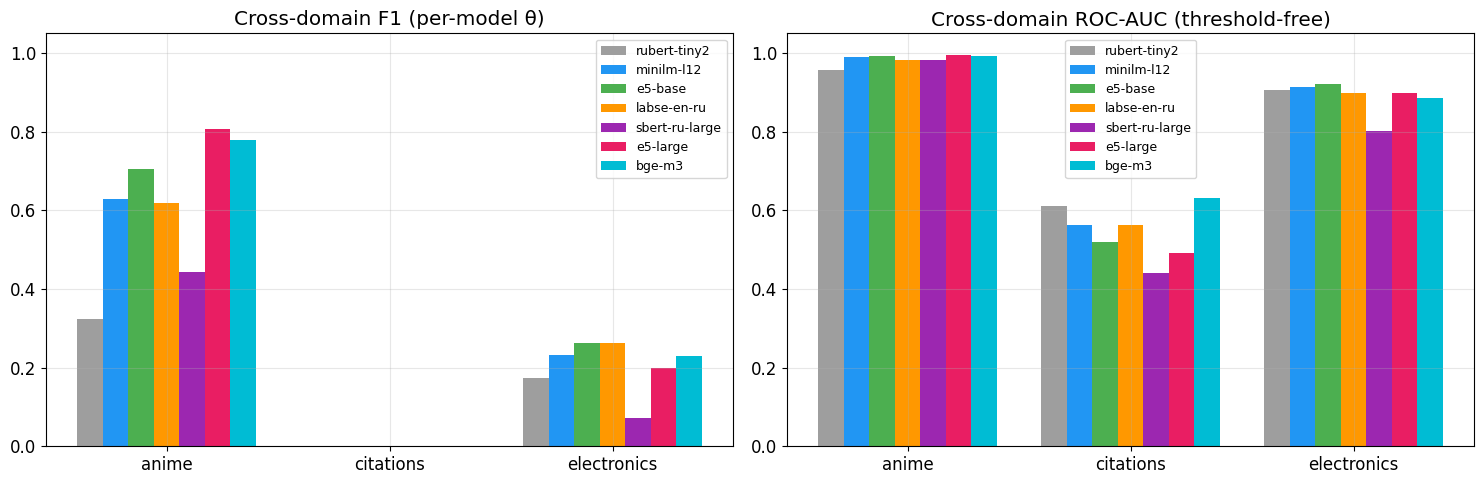

In [11]:
if not cd_df.empty:
    datasets = sorted(cd_df["dataset"].unique())
    tags = [t for t in MODEL_TAGS if t in results]
    x = np.arange(len(datasets))
    w = 0.8 / max(len(tags), 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, metric, title in [
        (axes[0], "F1", "Cross-domain F1 (per-model θ)"),
        (axes[1], "AUC", "Cross-domain ROC-AUC (threshold-free)"),
    ]:
        pivot = cd_df.pivot(index="tag", columns="dataset", values=metric).reindex(tags)
        for i, tag in enumerate(tags):
            offset = (i - (len(tags) - 1) / 2) * w
            ax.bar(x + offset, pivot.loc[tag, datasets].values, w, label=tag,
                   color=MODEL_COLORS[tag])
        ax.set_xticks(x); ax.set_xticklabels(datasets)
        ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

---
## 6. Выводы

Заполнить после запуска ячеек выше (см. `summary_df`, `cd_df`, графики качество–стоимость).

Шаблон:
- **Лучший по Test F1:** …
- **Лучший по Test ROC-AUC:** …
- **Лучший по cross-domain (среднее AUC по 3 датасетам):** …
- **Pareto-оптимальный по F1/время:** …
- **Неожиданности:** (например, `sbert-ru-large` учился 110 мин на эмбеддингах, но дал ли прирост?)